# 🎃 Seasonality: the Halloween / “Sell in May” effect

## 🧭 tl;dr

This notebook tests a calendar strategy that is invested from November through April and holds cash from May through October, then compares it with buy-and-hold SPY.

> Educational research only. This notebook is not financial advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Read from top to bottom: understand the economic idea, inspect the exact rule, then compare the formal test results with the robustness checks. Finish with <strong>What went well / what went wrong</strong> to see why a backtest is evidence—not proof.
</div>

## 🧭 Context & methods

Seasonality is a rules-based anomaly rather than a valuation or trend signal. The Halloween hypothesis predicts stronger average equity returns during November–April than during May–October. The cleanest test is deliberately simple: the calendar alone determines exposure.

### 🔧 Key assumptions

- Asset: SPY, used as a liquid broad-equity proxy.
- Long exposure is held during November through April; exposure is zero during May through October.
- The strategy changes exposure at the first trading day of each calendar season.
- No tax, bid-ask, or cash-yield assumptions are added beyond the standard transaction cost.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    dual_momentum_weights,
    inverse_volatility_weights,
    minimum_variance_weights,
    run_portfolio_backtest,
)
from src.research import metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The notebook uses adjusted daily closes when available. Missing assets are removed through a common-date intersection; if the download fails, deterministic demo data keeps the code path testable without pretending the synthetic results are market evidence.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '1993-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t)], axis=1)

close = close.dropna(how='any')
splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print('Assets:', ', '.join(close.columns))


Data: 1993-01-29 through 2025-12-31 (8,288 common trading days)
Assets: SPY


## 📜 Strategy rules

- **Invest:** November 1 through April 30.
- **Cash:** May 1 through October 31.
- **Execution:** the signal is shifted one bar by `run_backtest`, so a calendar change cannot earn the same day’s return.
- **Control:** compare after-cost seasonal exposure with buy-and-hold SPY.

The point is not to assume the effect is real; it is to test how much the conclusion changes with sample period and costs.

In [3]:
def halloween_target(index, long_months=(11, 12, 1, 2, 3, 4)):
    return pd.Series(index.month.isin(long_months).astype(float), index=index, name='target_position')

target = halloween_target(close.index)


## 📈 Formal test results

The untouched final 20% of the chronological sample is used for the headline table. Parameters are defined before reading the final test outputs.

In [4]:
seasonal_result = run_backtest(close['SPY'], target, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns)
buy_hold_result = run_backtest(close['SPY'], pd.Series(1.0, index=close.index), transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns)
result = seasonal_result
test_metrics = metrics_for_period(result, splits['test'].index)
test_table = pd.DataFrame([test_metrics], index=['Seasonality: the Halloween / “Sell in May” effect'])
format_map = {
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
}
display(test_table.style.format(format_map))
print('Formal test findings:')
print(f"  Sharpe={test_metrics['sharpe_ratio']:.2f} | annualized return={test_metrics['annualized_return']:.2%} | max drawdown={test_metrics['max_drawdown']:.2%}")


,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Seasonality: the Halloween / “Sell in May” effect,4.85%,16.35%,0.37,0.53,-33.72%,0.14,54.73%,1.98,13,36.52%,1.712922,-134.77%


Formal test findings:
  Sharpe=0.37 | annualized return=4.85% | max drawdown=-33.72%


## 📊 Equity curve and drawdown

The chart normalizes the strategy and SPY benchmark to one at the start of the formal test period. Drawdown is shown below it so a smooth return path is not mistaken for low risk.

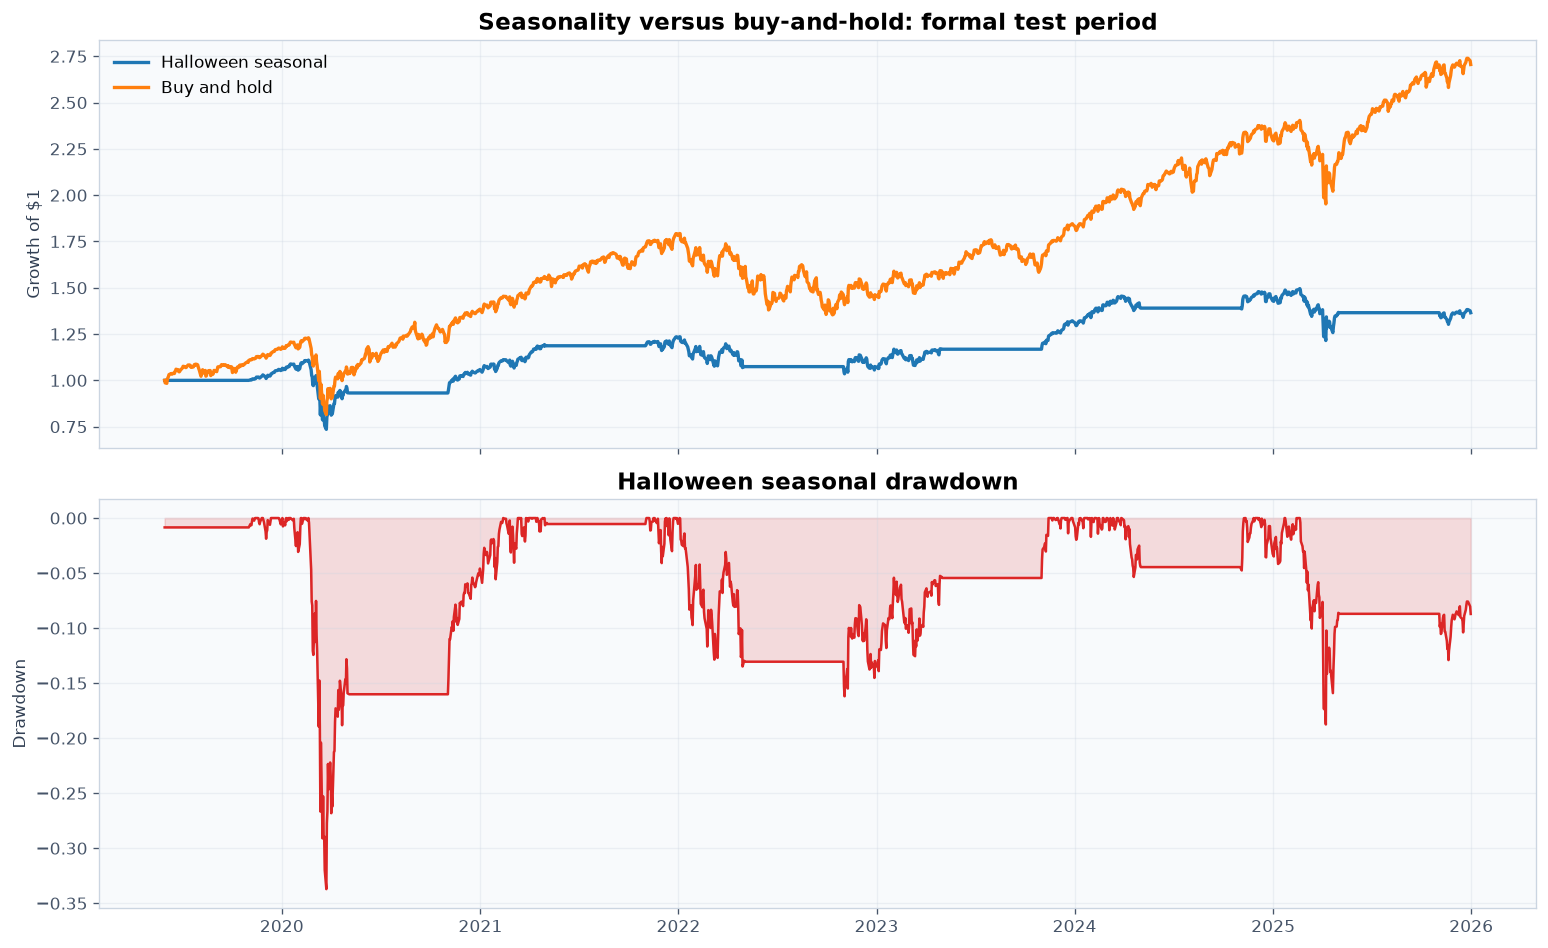

In [5]:
test_index = splits['test'].index
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for label, candidate in [('Halloween seasonal', seasonal_result), ('Buy and hold', buy_hold_result)]:
    curve = candidate.frame.loc[test_index, 'equity']
    axes[0].plot(curve.index, curve / curve.iloc[0], label=label, linewidth=2)
axes[0].set_title('Seasonality versus buy-and-hold: formal test period')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(seasonal_result.frame.loc[test_index].index, seasonal_result.frame.loc[test_index, 'drawdown'], color='#DC2626', linewidth=1.5)
axes[1].fill_between(test_index, seasonal_result.frame.loc[test_index, 'drawdown'], 0, color='#DC2626', alpha=0.15)
axes[1].set_title('Halloween seasonal drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.3)
plt.show()


## 🛡️ Robustness and crisis diagnostics

These checks are descriptive. Cost sensitivity shows how much implementation friction matters; crisis windows show failure modes and are not additional untouched test sets.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    candidate = run_candidate(cost_bps) if 'run_candidate' in locals() else None
    if candidate is None:
        if 'weights' in locals():
            candidate = run_portfolio_backtest(close, weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
        else:
            candidate = run_backtest(close.iloc[:, 0], target, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
    metrics = metrics_for_period(candidate, splits['test'].index)
    cost_rows.append({'cost_bps': cost_bps, 'test_return': metrics['annualized_return'], 'test_sharpe': metrics['sharpe_ratio'], 'max_drawdown': metrics['max_drawdown'], 'turnover': metrics['annualized_turnover']})
cost_table = pd.DataFrame(cost_rows).set_index('cost_bps')
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}', 'max_drawdown': '{:.2%}', 'turnover': '{:.2f}'}))

stress_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    if len(index) == 0:
        continue
    returns = result.frame.loc[index, 'net_returns']
    path = (1.0 + returns).cumprod()
    stress_rows.append({'window': window, 'return': path.iloc[-1] - 1.0, 'max_drawdown': (path / path.cummax() - 1.0).min()})
stress_table = pd.DataFrame(stress_rows).set_index('window')
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))


,test_return,test_sharpe,max_drawdown,turnover
cost_bps,,,,
0,5.05%,0.38,-33.72%,1.98
5,4.95%,0.38,-33.72%,1.98
10,4.85%,0.37,-33.72%,1.98
25,4.53%,0.35,-33.72%,1.98
50,4.02%,0.32,-33.72%,1.98


,return,max_drawdown
window,,
Global Financial Crisis,-21.75%,-33.84%
COVID shock,-33.40%,-33.72%
2022 inflation/rates shock,-12.55%,-13.49%


## ⚖️ What went well / what went wrong

**What went well:** The strategy is fully specified before looking at returns, has low turnover, and offers a clean example of how calendar rules can be tested without indicator overfitting.

**What went wrong:** Seasonality can weaken after publication, vary by country and era, and reflect changing tax, liquidity, or investor behavior. A six-month cash period can also miss strong summer rallies.

**Research judgment:** A full-sample average is not enough: inspect the year-by-year seasonal returns and whether the effect survives a recent out-of-sample period.

> The displayed metrics are sample-specific proxy results. They should be interpreted alongside costs, turnover, stress windows, and implementation gaps.